In [4]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

In [5]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [6]:
reload(helpers)
parts = 10

pops = [
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/qcflag-5", parts, label="Static potential", colour="black"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/time-evolving-pot", parts, label="Evolving potential", colour="tab:purple"),
]

Loading distributed population Static potential from 10 parts
   loaded part 1/10 of Static potential with 179379 binaries
   loaded part 2/10 of Static potential with 178696 binaries
   loaded part 3/10 of Static potential with 177856 binaries
   loaded part 4/10 of Static potential with 178671 binaries
   loaded part 5/10 of Static potential with 179015 binaries
   loaded part 6/10 of Static potential with 179239 binaries
   loaded part 7/10 of Static potential with 178912 binaries
   loaded part 8/10 of Static potential with 178218 binaries
   loaded part 9/10 of Static potential with 179055 binaries
   loaded part 10/10 of Static potential with 179140 binaries
Loading distributed population Evolving potential from 10 parts
   loaded part 1/10 of Evolving potential with 179379 binaries
   loaded part 2/10 of Evolving potential with 178696 binaries
   loaded part 3/10 of Evolving potential with 177856 binaries
   loaded part 4/10 of Evolving potential with 178671 binaries
   loaded p

In [7]:
kinematics = helpers.get_kinematics(pops)

In [8]:
print("Escaped fractions:")
for pop in pops:
    escaped = kinematics[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {kinematics[pop.label]["escaped"]["CO"].sum() / len(kinematics[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {kinematics[pop.label]["escaped"]["BH"].sum() / len(kinematics[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {kinematics[pop.label]["escaped"]["NS"].sum() / len(kinematics[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Static potential:
      - CO = 0.107
      - BH = 0.029
      - NS = 0.136
  - Evolving potential:
      - CO = 0.191
      - BH = 0.066
      - NS = 0.240


Inner 10 kpc
  Static potential fraction within 0.5 kpc 0.49
  Evolving potential fraction within 0.5 kpc 0.25
Full population
  Static potential fraction within 0.5 kpc 0.39
  Evolving potential fraction within 0.5 kpc 0.16


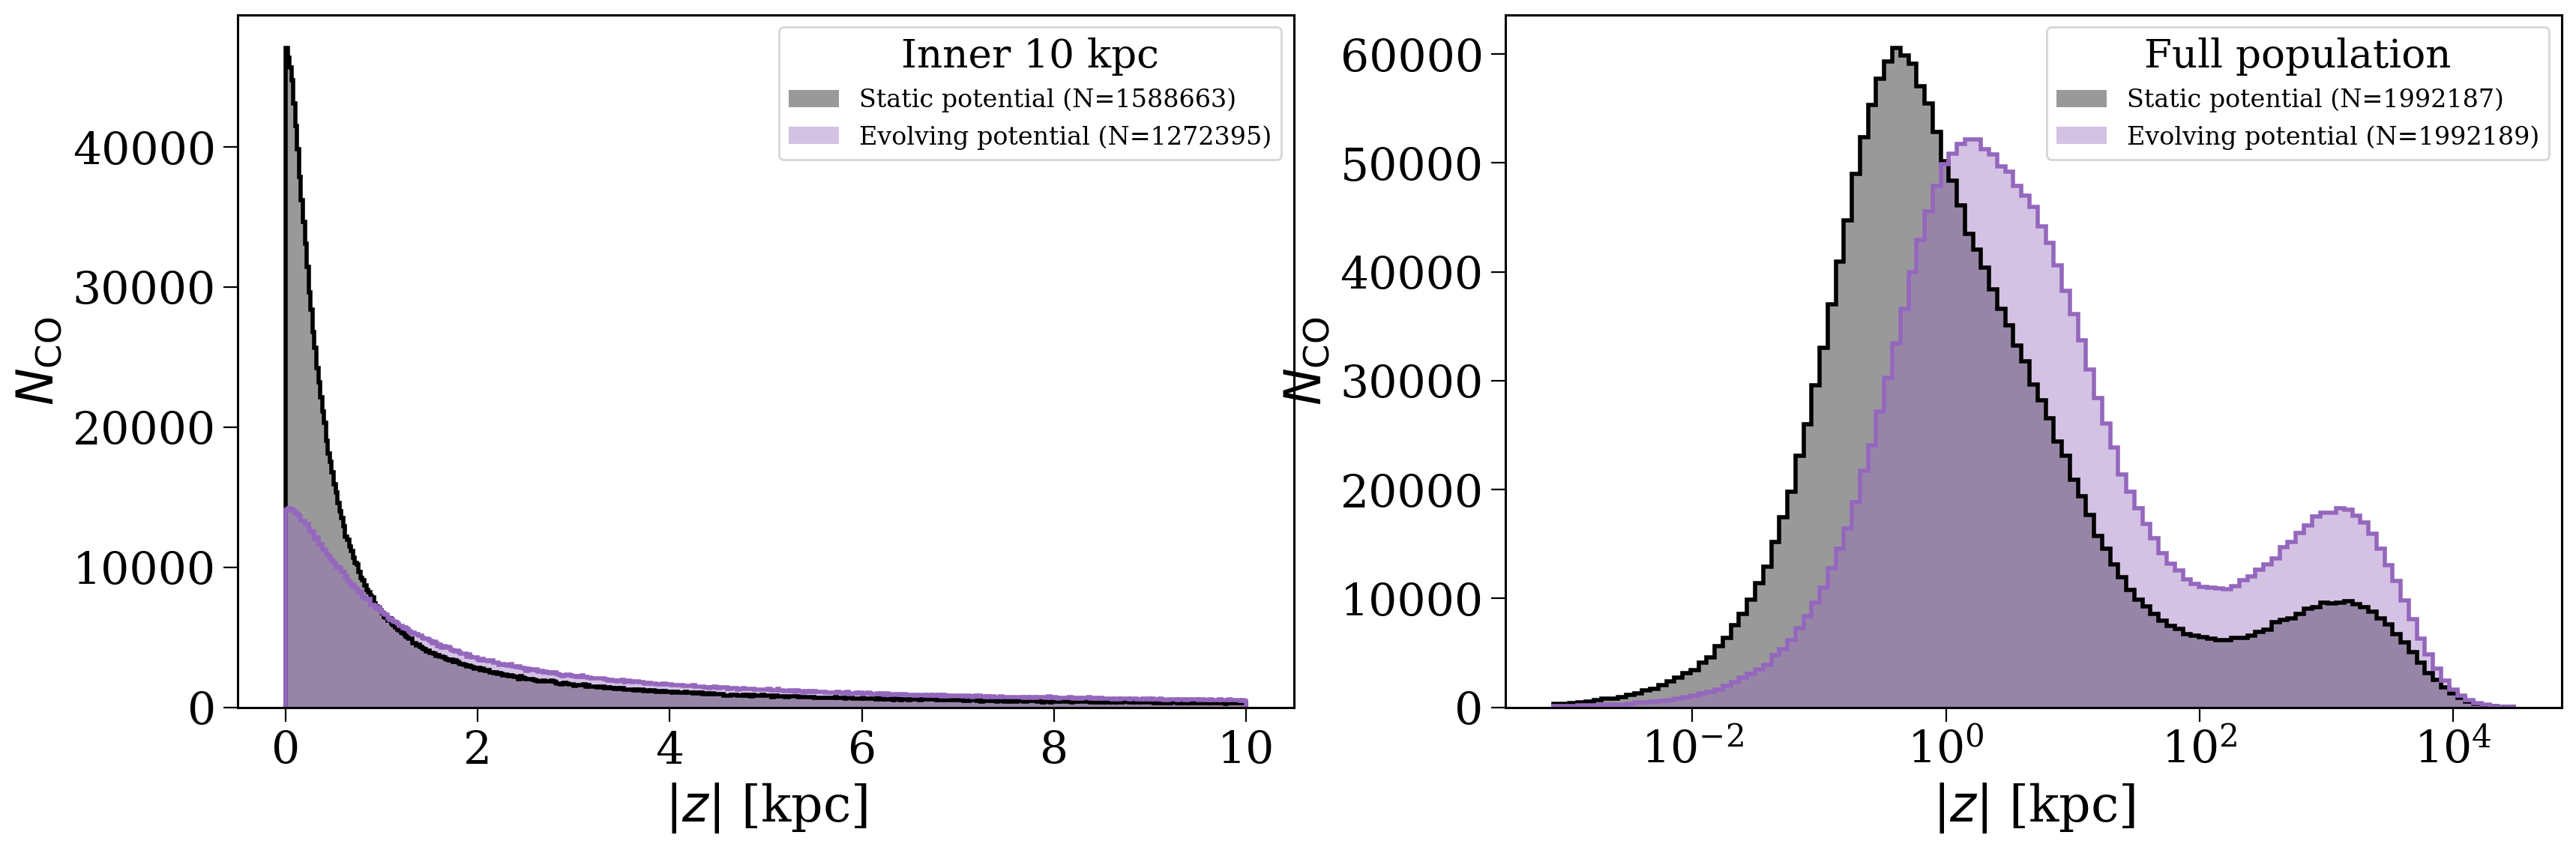

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [9]:
plotting.absolute_galactocentric_height(pops, kinematics)

[ 2.64104653  9.11581279 17.60315171 19.93868871]
[ 2.89623849 13.83387539  9.9782138  15.09025486]


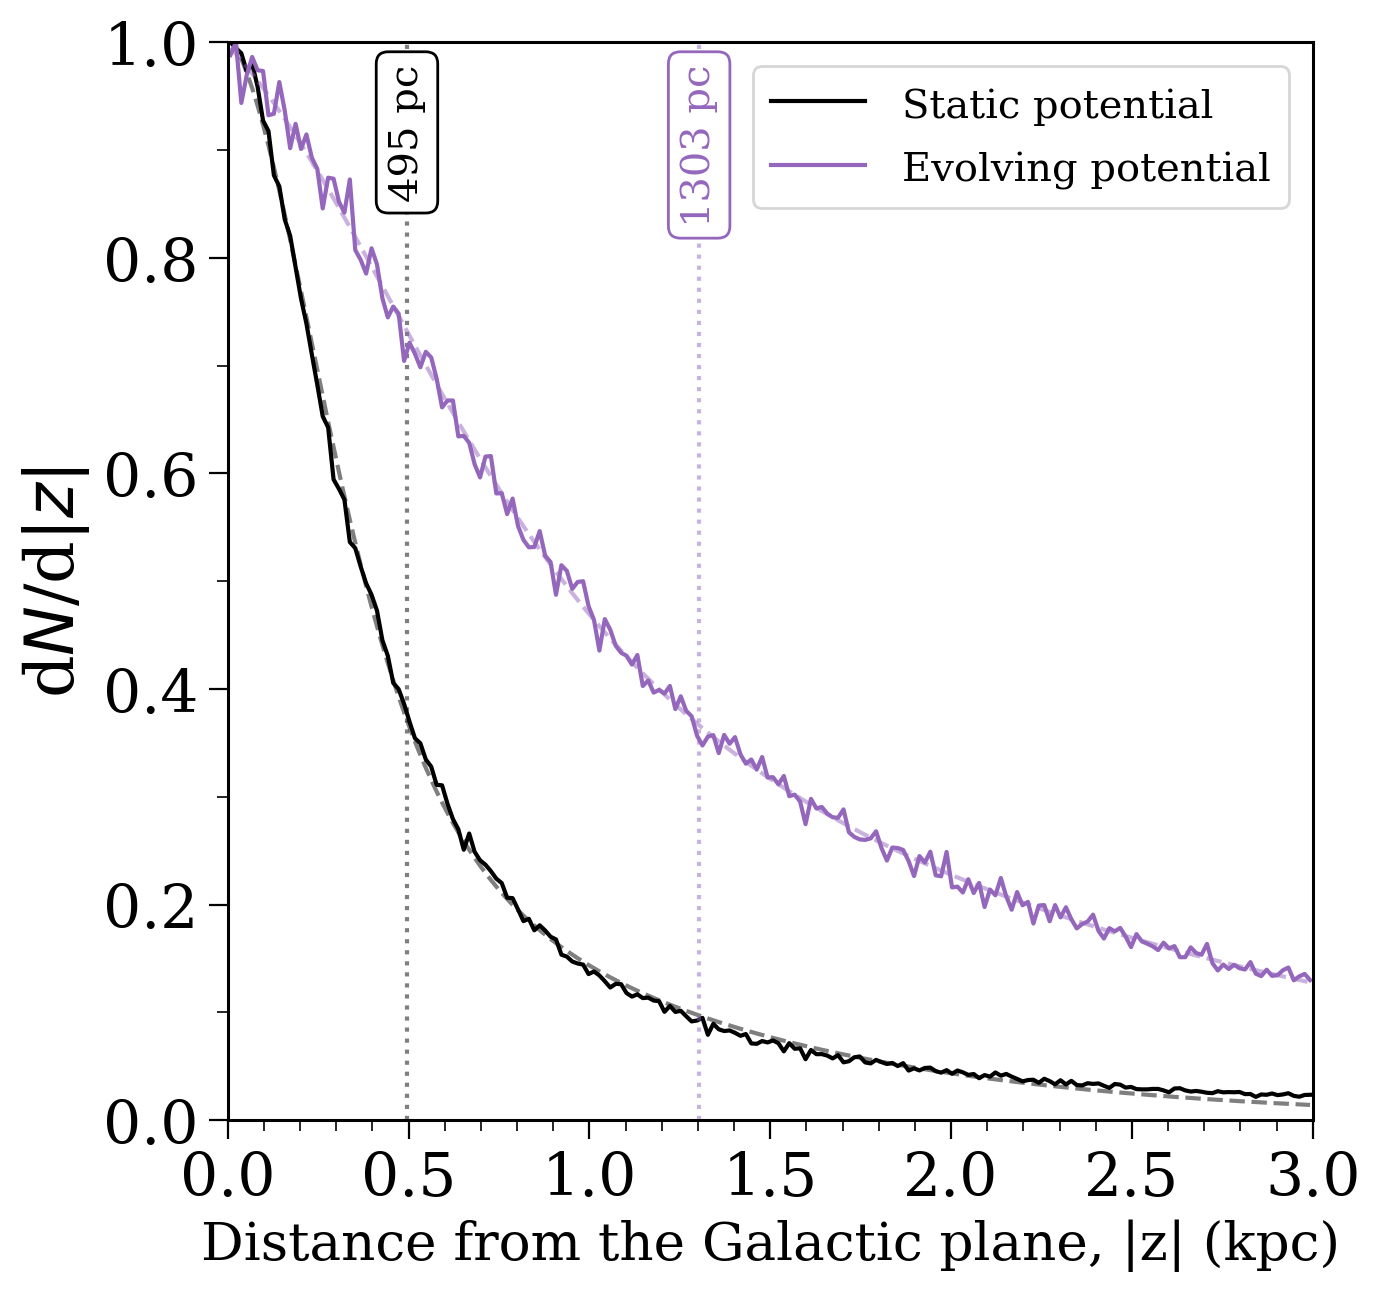

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for pop in pops:

    scale_height, _, _ = plotting.estimate_scale_height(
        z=kinematics[pop.label]["pos"]["BH"][:, 2],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_locs=[0.98, 0.98],
        R=None,
    )

leg = ax.get_legend()
for text in leg.get_texts():
    text.set_fontsize(0.6 * fs)

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_time_evolving.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [11]:
mass = {}
for pop in pops:

    masses = {
        "BH": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
        )),
        "NS": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
        )),
    }
    masses["CO"] = np.concatenate((masses["NS"], masses["BH"]))

    mass[pop.label] = masses

In [12]:
z_range = np.geomspace(0.1, 10, 1000)

init_bh_z = np.concatenate((
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_1"] == 14],
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_2"] == 14]
))
init_abs_z = np.abs(init_bh_z.to(u.kpc).value)

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value)
            for pop in pops] + [init_abs_z],
    bh_masses=[masses["BH"], masses["BH"], masses["BH"]],
    z_range=z_range,
    window_width=0.1
)

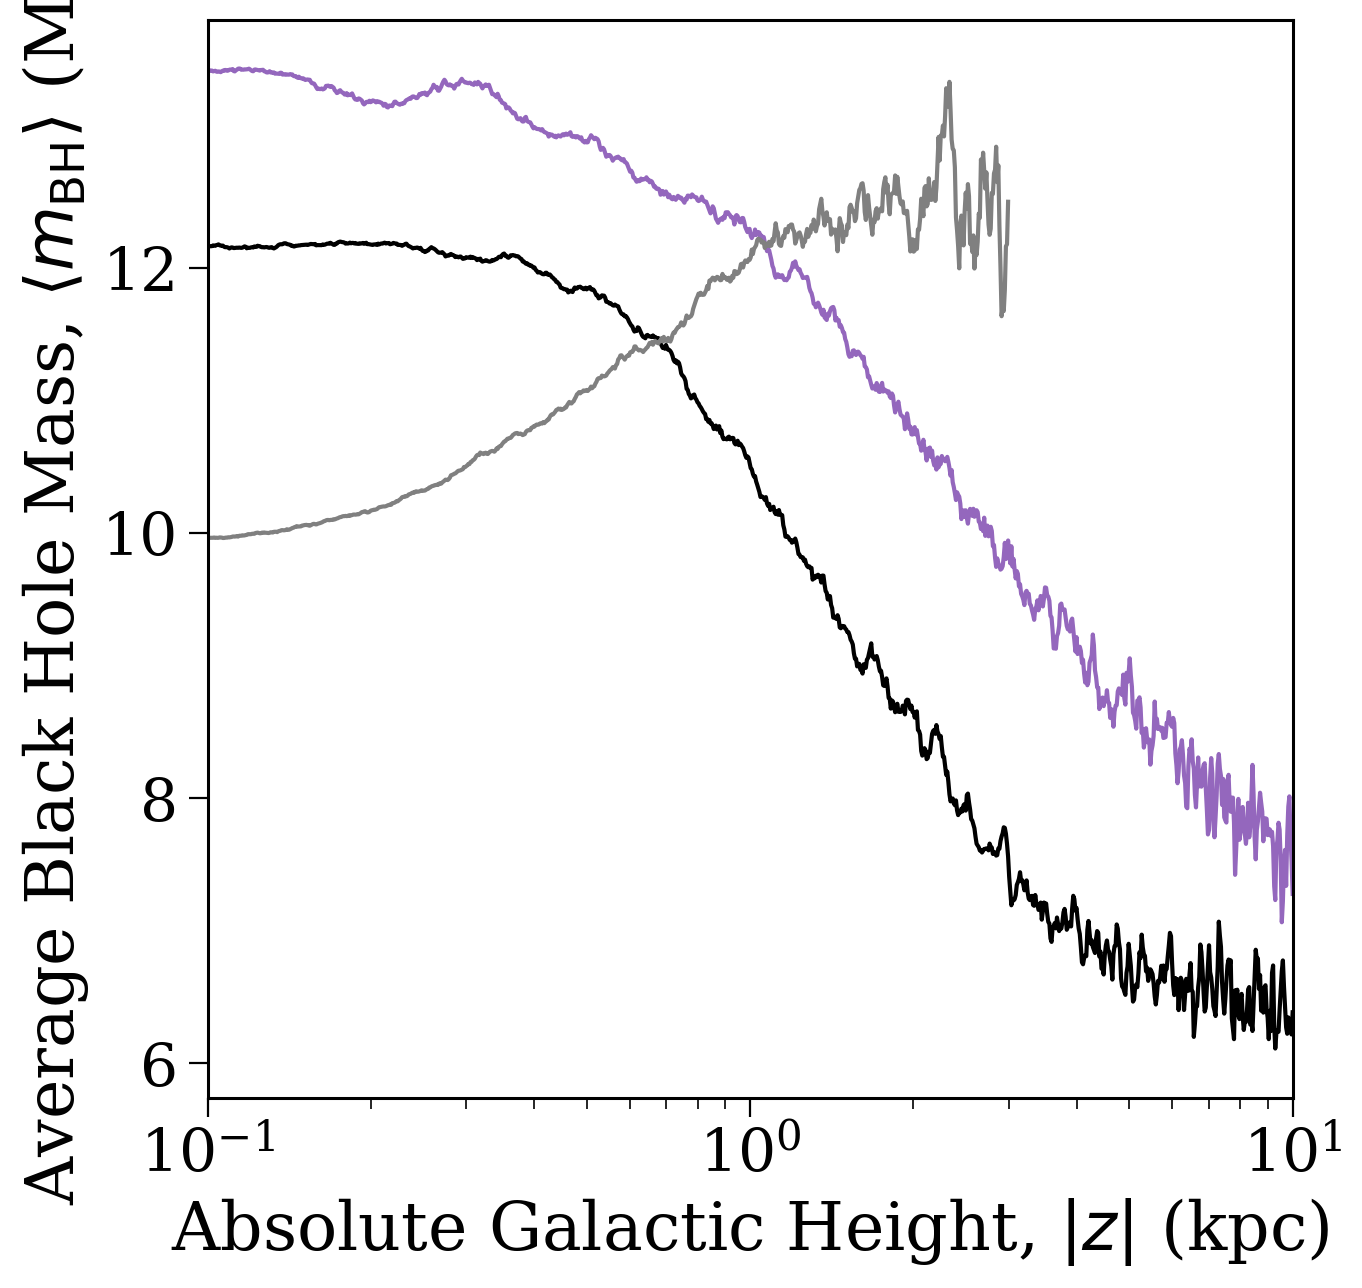

In [14]:
fig, ax = plt.subplots(figsize=(7, 7))

for i, pop in enumerate(pops):
    ax.plot(z_range, mean_masses[i], label=pop.label, color=pop.colour)
ax.plot(z_range[z_range < 3], mean_masses[-1][z_range < 3],
        label="Initial BHs", color="grey")

ax.set(
    xscale='log',
    xlabel=r'Absolute Galactic Height, $|z|$ (kpc)',
    ylabel=r'Average Black Hole Mass, $\langle m_{\rm BH} \rangle$ (M$_\odot$)',
    xlim=(0.1, 10),
)

plt.show()